In [24]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

# # # # # # # # # # # 
# tag = '2022041804_04_1000n_test_32neigh_mindist0pt1'
# tag = '2022041809_a04_1000n_test_32neigh_mindist0pt1'
# tag = '2022050219_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1'


# tag = '2022041804_04_12000n_extended_32neigh_mindist0pt1'
# tag = '2022041807_a03_12000n_extended_32neigh_mindist0pt1'
# tag = '2022041809_a04_12000n_extended_32neigh_mindist0pt1'
tag = '2022050223_baseline_2000n_extended_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1'
# # # # # # # # # # # 

rdir = '/home/kat/Repos/SALSA/results/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pandas as pd
from rdkit.Chem import PandasTools

df = pd.read_csv(f'{rdir}umap_dfs/{tag}.csv')
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype","x","y"]]

### Scatter plots color-coded by property.

In [26]:
from rdkit.Chem import rdMolDescriptors, Descriptors, Crippen
my_props = [(Descriptors.MolWt, "MolWt"),
            (Descriptors.HeavyAtomCount, "HeavyAtomCount"), 
            (Descriptors.FractionCSP3, "FractionCSP3"), 
            (Descriptors.TPSA, "TPSA"), 
            (Descriptors.NumHAcceptors, "NumHAcceptors"), 
            (Descriptors.NumHDonors, "NumHDonors"), 
            (Descriptors.NumRotatableBonds, "NumRotatableBonds"), 
            (Crippen.MolLogP, "MolLogP"),
           ]

my_props_names = [x[1] for x in my_props]
    
# usecols = ['HeavyAtomCount','FractionCSP3', 'TPSA', 
#            'NumRotatableBonds', 'MolLogP']

usecols = ['TPSA','HeavyAtomCount', 'NumRotatableBonds', 
           'FractionCSP3', 'MolLogP']

for descriptor, name in my_props:
    if name not in usecols:
        continue
    props = [descriptor(m) for m in df.Mol] 
    df[name] = props

In [21]:
# import seaborn as sns 
# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(ncols=2,nrows=3,figsize=(20,30)) #,aspect='equal') 
# for i,prop in enumerate(usecols):
#     ii = i+1
#     row = ii//2
#     col = ii%2
#     fig = sns.scatterplot(data=df, x='x', y='y', hue=prop,
#                           alpha=0.75, s=5, palette='plasma', ax=axs[row][col]) 
#     fig.axes.get_xaxis().set_visible(False)
#     fig.axes.get_yaxis().set_visible(False) 
# plt.subplots_adjust(wspace=.05, hspace=.05)
# axs[0,0].set_axis_off()
# display()

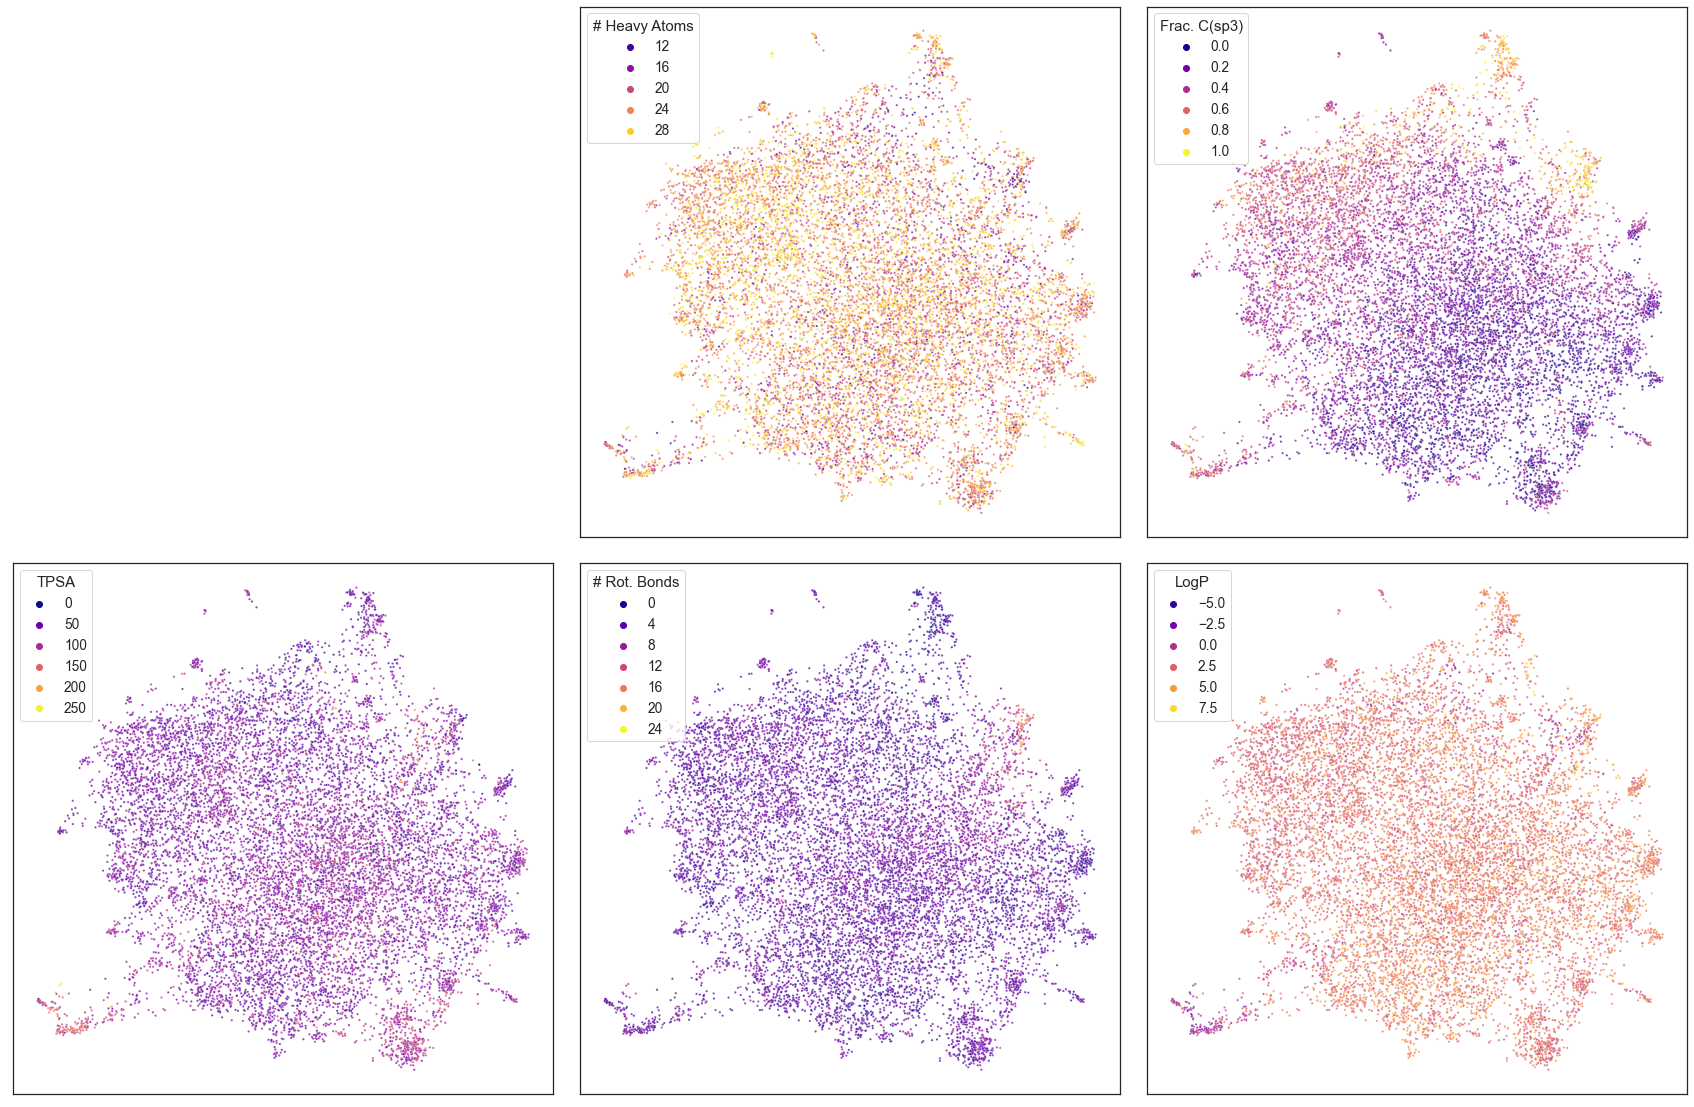

In [27]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.25) 

fig, axs = plt.subplots(ncols=3,nrows=2,figsize=(30,20)) #,aspect='equal') 
for i,prop in enumerate(usecols):
    ii = i+1
    col = ii//2
    row = ii%2
    fig = sns.scatterplot(data=df, x='x', y='y', hue=prop,
                          alpha=0.75, s=5, palette='plasma', ax=axs[row][col]) 
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False) 
    fig.legend(loc="upper left")
    
    if prop=='NumRotatableBonds':
        fig.get_legend().set_title("# Rot. Bonds")
    elif prop=='HeavyAtomCount':
        fig.get_legend().set_title("# Heavy Atoms")
    elif prop=='FractionCSP3':
        fig.get_legend().set_title("Frac. C(sp3)")
    elif prop=='MolLogP':
        fig.get_legend().set_title("LogP")
    else:
        fig.get_legend().set_title(prop)
        
plt.subplots_adjust(wspace=.05, hspace=.05)
axs[0,0].set_axis_off()
display()